In [1]:
import sklearn
print("scikit-learn version:", sklearn.__version__)
print("Ready to use Neural Networks!")

scikit-learn version: 1.7.2
Ready to use Neural Networks!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('mnist_train.csv')
test_df = pd.read_csv('mnist_test.csv')

train_df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (60000, 785)
Test shape: (10000, 785)


In [4]:
print("Missing in train:", train_df.isnull().sum().sum())
print("Missing in test:", test_df.isnull().sum().sum())

Missing in train: 0
Missing in test: 0


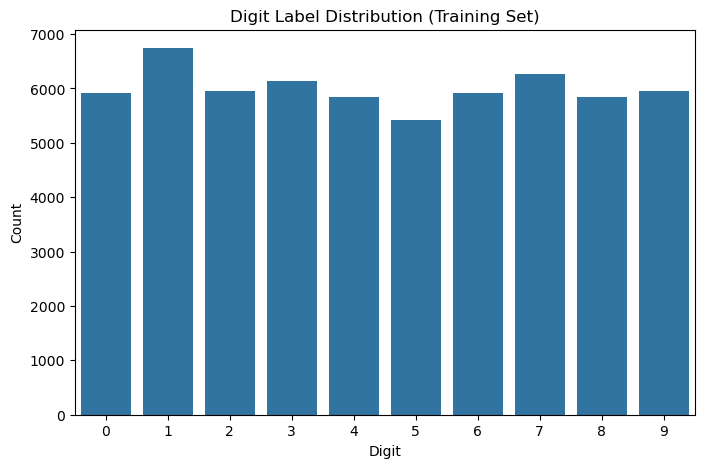

In [5]:
plt.figure(figsize=(8,5))
sns.countplot(x=train_df['label'])
plt.title('Digit Label Distribution (Training Set)')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.show()

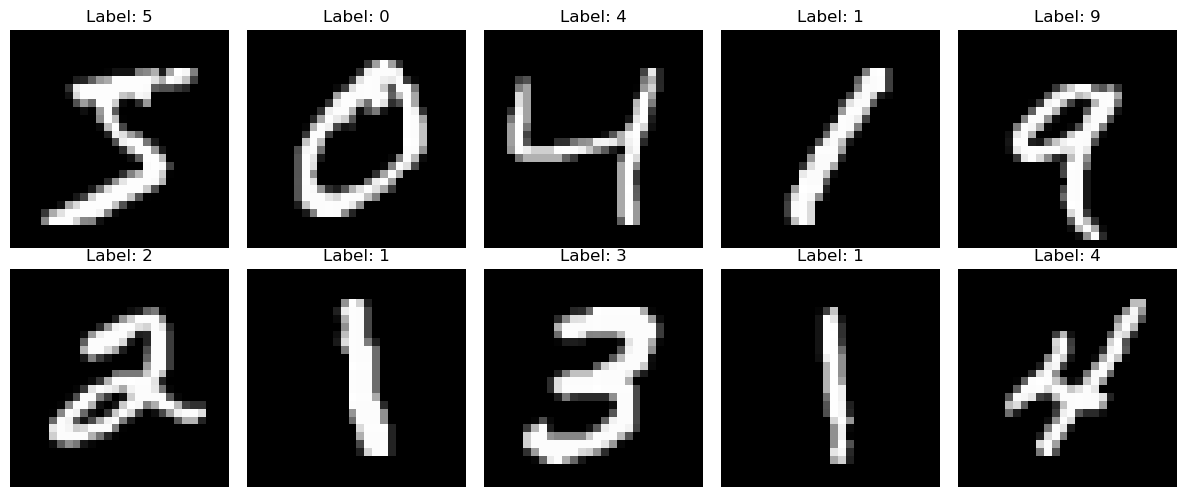

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(12,5))

for i, ax in enumerate(axes.flat):
    image = train_df.iloc[i, 1:].values.reshape(28, 28)
    label = train_df.iloc[i, 0]
    ax.imshow(image, cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [7]:
X_train = train_df.drop(columns=['label']).values
y_train = train_df['label'].values

X_test = test_df.drop(columns=['label']).values
y_test = test_df['label'].values

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (60000, 784)
X_test shape: (10000, 784)


In [8]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("Pixel value range after normalization:", X_train.min(), "to", X_train.max())

Pixel value range after normalization: 0.0 to 1.0


In [9]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=30,
    early_stopping=True,
    random_state=42,
    verbose=True
)

mlp_model.fit(X_train, y_train)
print("Neural Network trained successfully!")

Iteration 1, loss = 0.40444698
Validation score: 0.939167
Iteration 2, loss = 0.16155774
Validation score: 0.959167
Iteration 3, loss = 0.11461624
Validation score: 0.964833
Iteration 4, loss = 0.08749173
Validation score: 0.965167
Iteration 5, loss = 0.07013413
Validation score: 0.970667
Iteration 6, loss = 0.05688478
Validation score: 0.971333
Iteration 7, loss = 0.04665649
Validation score: 0.971833
Iteration 8, loss = 0.03684816
Validation score: 0.974833
Iteration 9, loss = 0.03008872
Validation score: 0.973500
Iteration 10, loss = 0.02720634
Validation score: 0.974000
Iteration 11, loss = 0.02256544
Validation score: 0.975000
Iteration 12, loss = 0.01872728
Validation score: 0.977333
Iteration 13, loss = 0.01580341
Validation score: 0.973000
Iteration 14, loss = 0.01219610
Validation score: 0.975833
Iteration 15, loss = 0.01024761
Validation score: 0.976333
Iteration 16, loss = 0.00856973
Validation score: 0.977833
Iteration 17, loss = 0.01124879
Validation score: 0.974167
Iterat

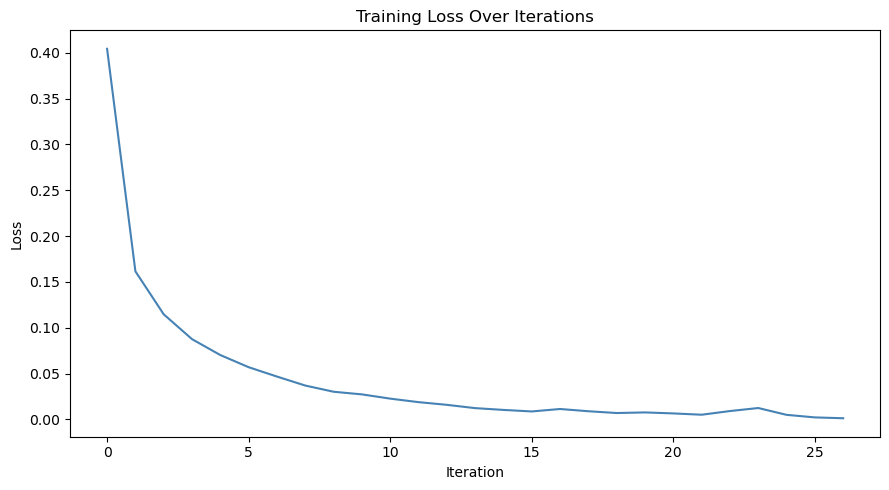

In [10]:
plt.figure(figsize=(9,5))
plt.plot(mlp_model.loss_curve_, color='steelblue')
plt.title('Training Loss Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import accuracy_score

y_pred = mlp_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9780


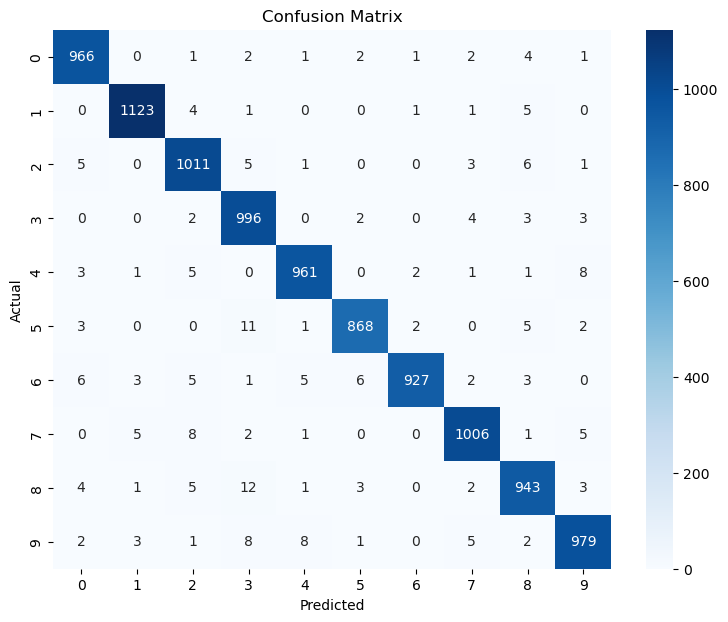

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.96      0.99      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.98       892
           6       0.99      0.97      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [12]:
from sklearn.metrics import confusion_matrix, classification_report

plt.figure(figsize=(9,7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, y_pred))

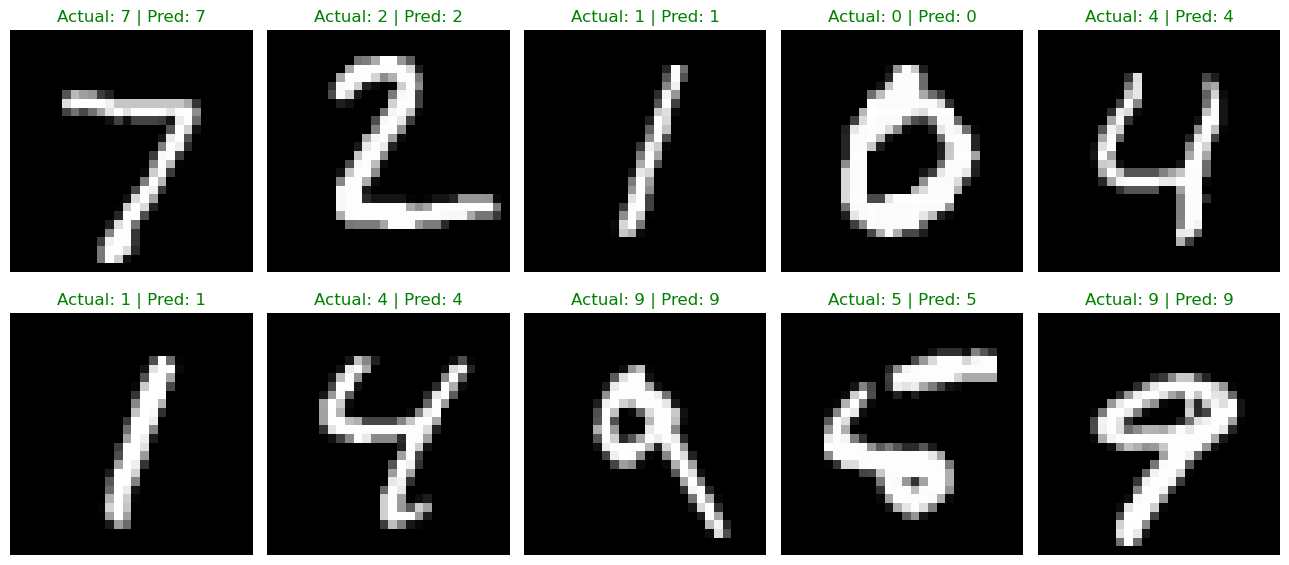

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(13,6))

for i, ax in enumerate(axes.flat):
    image = X_test[i].reshape(28, 28)
    actual = y_test[i]
    predicted = y_pred[i]
    color = 'green' if actual == predicted else 'red'

    ax.imshow(image, cmap='gray')
    ax.set_title(f"Actual: {actual} | Pred: {predicted}", color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [14]:
import joblib

joblib.dump(mlp_model, 'mnist_digit_model.pkl')
print("Model saved as 'mnist_digit_model.pkl'")

Model saved as 'mnist_digit_model.pkl'
